In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load datasets
ibm = pd.read_csv('IBM Transaction Dataset/HI-Small_Trans.csv')
baf = pd.read_csv('BAF NeurIPS Dataset/Base.csv')

print("✅ IBM Shape:", ibm.shape)
print("✅ BAF Shape:", baf.shape)

✅ IBM Shape: (5078345, 11)
✅ BAF Shape: (1000000, 32)


In [2]:
print("="*50)
print("IBM DATASET ANALYSIS")
print("="*50)

# Basic info
print(f"\nTotal transactions:  {len(ibm):,}")
print(f"Total columns:       {ibm.shape[1]}")
print(f"\nFraud transactions:  {ibm['Is Laundering'].sum():,}")
print(f"Legit transactions:  {(ibm['Is Laundering']==0).sum():,}")
print(f"Fraud percentage:    {ibm['Is Laundering'].mean()*100:.2f}%")

print("\n--- Column Info ---")
print(ibm.dtypes)

print("\n--- Missing Values ---")
print(ibm.isnull().sum())

IBM DATASET ANALYSIS

Total transactions:  5,078,345
Total columns:       11

Fraud transactions:  5,177
Legit transactions:  5,073,168
Fraud percentage:    0.10%

--- Column Info ---
Timestamp              object
From Bank               int64
Account                object
To Bank                 int64
Account.1              object
Amount Received       float64
Receiving Currency     object
Amount Paid           float64
Payment Currency       object
Payment Format         object
Is Laundering           int64
dtype: object

--- Missing Values ---
Timestamp             0
From Bank             0
Account               0
To Bank               0
Account.1             0
Amount Received       0
Receiving Currency    0
Amount Paid           0
Payment Currency      0
Payment Format        0
Is Laundering         0
dtype: int64


In [3]:
print("="*50)
print("BAF NEURIPS DATASET ANALYSIS")
print("="*50)

print(f"\nTotal applications:  {len(baf):,}")
print(f"Total features:      {baf.shape[1]}")
print(f"\nFraud applications:  {baf['fraud_bool'].sum():,}")
print(f"Legit applications:  {(baf['fraud_bool']==0).sum():,}")
print(f"Fraud percentage:    {baf['fraud_bool'].mean()*100:.2f}%")

print("\n--- Column Info ---")
print(baf.dtypes)

print("\n--- Missing Values ---")
print(baf.isnull().sum())

BAF NEURIPS DATASET ANALYSIS

Total applications:  1,000,000
Total features:      32

Fraud applications:  11,029
Legit applications:  988,971
Fraud percentage:    1.10%

--- Column Info ---
fraud_bool                            int64
income                              float64
name_email_similarity               float64
prev_address_months_count             int64
current_address_months_count          int64
customer_age                          int64
days_since_request                  float64
intended_balcon_amount              float64
payment_type                         object
zip_count_4w                          int64
velocity_6h                         float64
velocity_24h                        float64
velocity_4w                         float64
bank_branch_count_8w                  int64
date_of_birth_distinct_emails_4w      int64
employment_status                    object
credit_risk_score                     int64
email_is_free                         int64
housing_status   

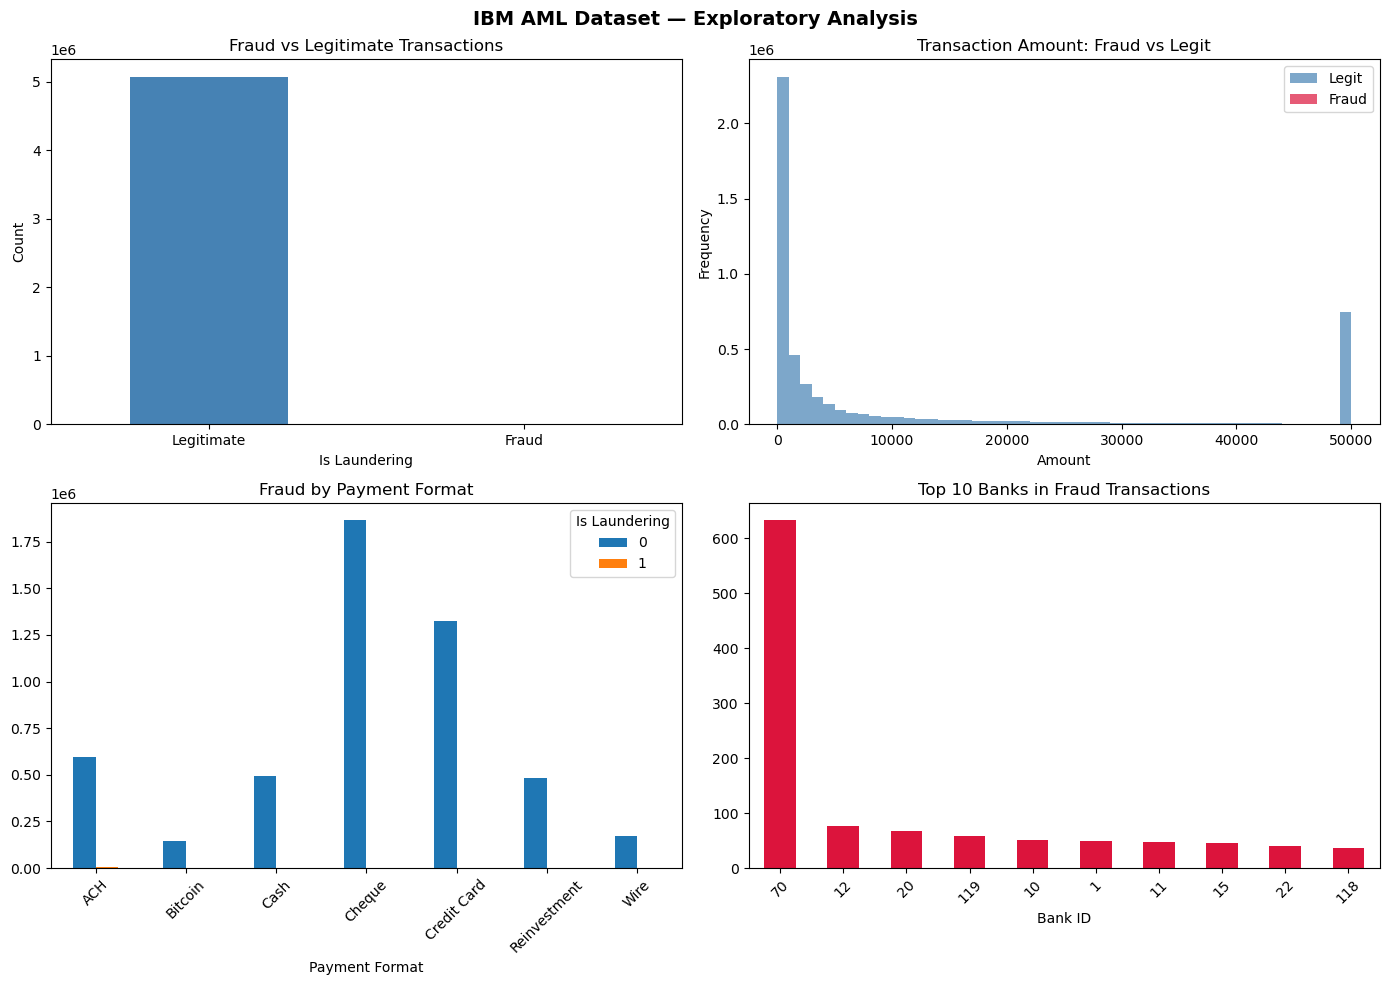

✅ Plot saved as ibm_eda.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('IBM AML Dataset — Exploratory Analysis', fontsize=14, fontweight='bold')

# Plot 1: Fraud vs Legit count
ibm['Is Laundering'].value_counts().plot(
    kind='bar', ax=axes[0,0], color=['steelblue','crimson'],
    title='Fraud vs Legitimate Transactions'
)
axes[0,0].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)
axes[0,0].set_ylabel('Count')

# Plot 2: Transaction amount distribution
ibm[ibm['Is Laundering']==0]['Amount Paid'].clip(upper=50000).plot(
    kind='hist', bins=50, ax=axes[0,1], color='steelblue', alpha=0.7, label='Legit'
)
ibm[ibm['Is Laundering']==1]['Amount Paid'].clip(upper=50000).plot(
    kind='hist', bins=50, ax=axes[0,1], color='crimson', alpha=0.7, label='Fraud'
)
axes[0,1].set_title('Transaction Amount: Fraud vs Legit')
axes[0,1].set_xlabel('Amount')
axes[0,1].legend()

# Plot 3: Payment format breakdown
ibm.groupby(['Payment Format','Is Laundering']).size().unstack().plot(
    kind='bar', ax=axes[1,0], title='Fraud by Payment Format'
)
axes[1,0].set_xlabel('Payment Format')
axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=45)

# Plot 4: Top banks involved in fraud
top_fraud_banks = ibm[ibm['Is Laundering']==1]['From Bank'].value_counts().head(10)
top_fraud_banks.plot(kind='bar', ax=axes[1,1], color='crimson',
                     title='Top 10 Banks in Fraud Transactions')
axes[1,1].set_xlabel('Bank ID')
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('ibm_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved as ibm_eda.png")

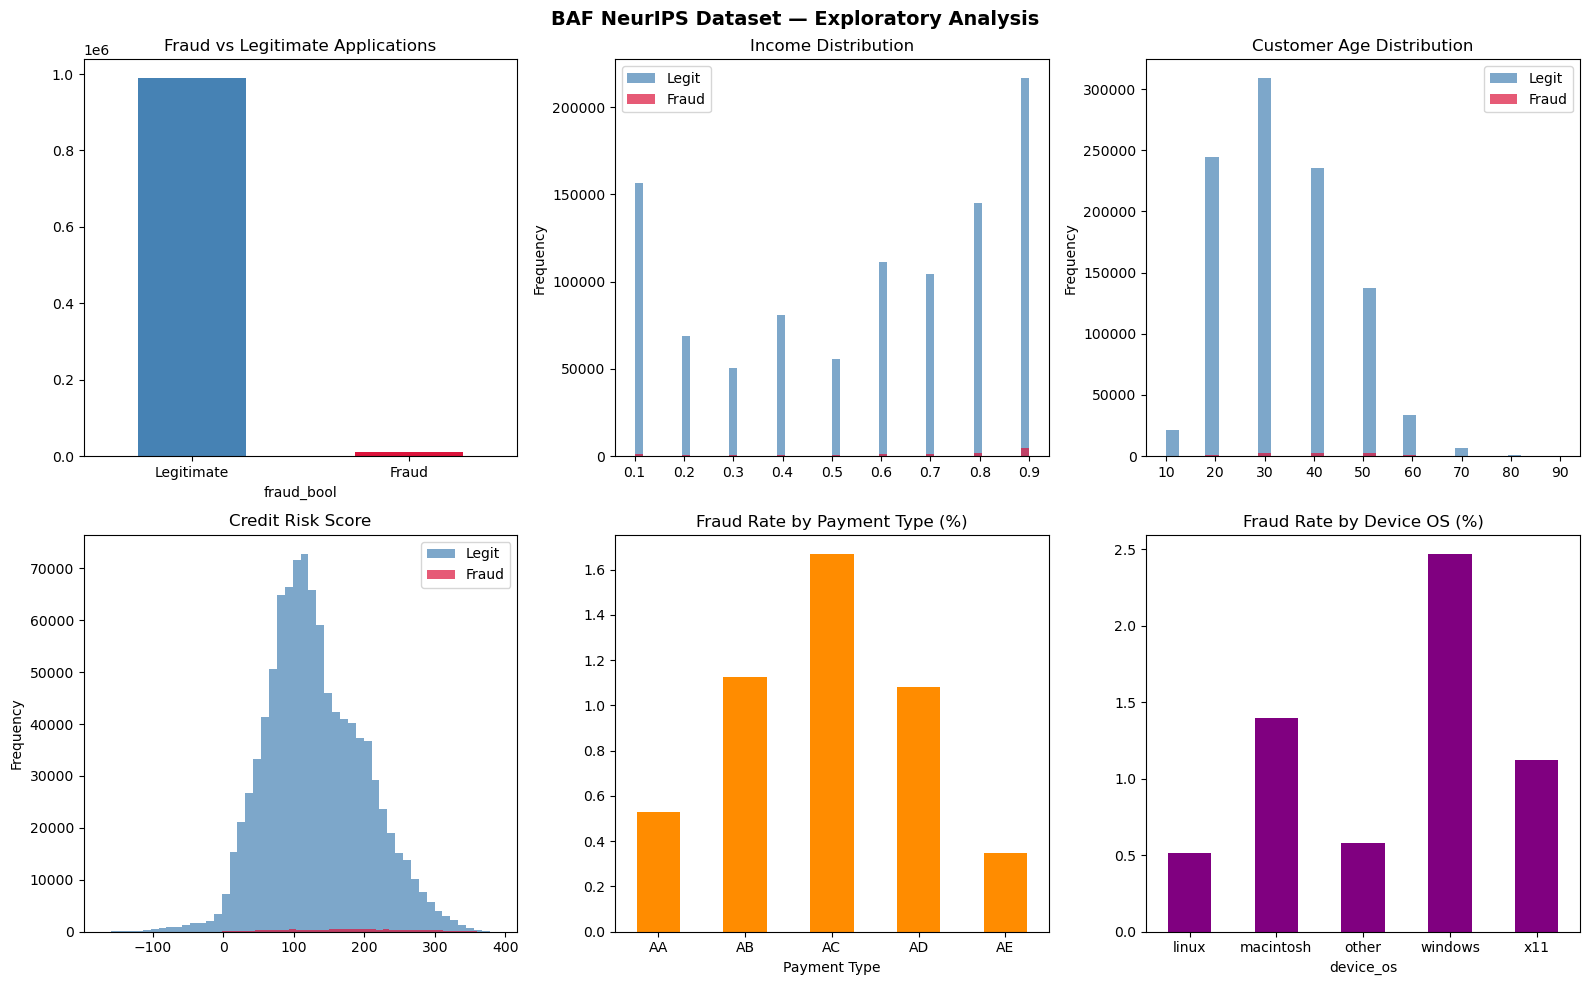

✅ Plot saved as baf_eda.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('BAF NeurIPS Dataset — Exploratory Analysis', fontsize=14, fontweight='bold')

# Plot 1: Fraud vs Legit
baf['fraud_bool'].value_counts().plot(
    kind='bar', ax=axes[0,0], color=['steelblue','crimson'],
    title='Fraud vs Legitimate Applications'
)
axes[0,0].set_xticklabels(['Legitimate','Fraud'], rotation=0)

# Plot 2: Income distribution
baf[baf['fraud_bool']==0]['income'].plot(
    kind='hist', bins=50, ax=axes[0,1], color='steelblue', alpha=0.7, label='Legit'
)
baf[baf['fraud_bool']==1]['income'].plot(
    kind='hist', bins=50, ax=axes[0,1], color='crimson', alpha=0.7, label='Fraud'
)
axes[0,1].set_title('Income Distribution')
axes[0,1].legend()

# Plot 3: Customer age
baf[baf['fraud_bool']==0]['customer_age'].plot(
    kind='hist', bins=30, ax=axes[0,2], color='steelblue', alpha=0.7, label='Legit'
)
baf[baf['fraud_bool']==1]['customer_age'].plot(
    kind='hist', bins=30, ax=axes[0,2], color='crimson', alpha=0.7, label='Fraud'
)
axes[0,2].set_title('Customer Age Distribution')
axes[0,2].legend()

# Plot 4: Credit risk score
baf[baf['fraud_bool']==0]['credit_risk_score'].plot(
    kind='hist', bins=50, ax=axes[1,0], color='steelblue', alpha=0.7, label='Legit'
)
baf[baf['fraud_bool']==1]['credit_risk_score'].plot(
    kind='hist', bins=50, ax=axes[1,0], color='crimson', alpha=0.7, label='Fraud'
)
axes[1,0].set_title('Credit Risk Score')
axes[1,0].legend()

# Plot 5: Payment type fraud rate
payment_fraud = baf.groupby('payment_type')['fraud_bool'].mean() * 100
payment_fraud.plot(kind='bar', ax=axes[1,1], color='darkorange',
                   title='Fraud Rate by Payment Type (%)')
axes[1,1].set_xlabel('Payment Type')
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=0)

# Plot 6: Device OS fraud rate
device_fraud = baf.groupby('device_os')['fraud_bool'].mean() * 100
device_fraud.plot(kind='bar', ax=axes[1,2], color='purple',
                  title='Fraud Rate by Device OS (%)')
axes[1,2].set_xticklabels(axes[1,2].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('baf_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved as baf_eda.png")

In [6]:
print("="*55)
print("  SUMMARY — READY FOR YOUR PROJECT REPORT")
print("="*55)

print("\n📊 IBM AML Dataset:")
print(f"   • {len(ibm):,} total transactions")
print(f"   • {ibm['Account'].nunique():,} unique sender accounts")
print(f"   • {ibm['Account.1'].nunique():,} unique receiver accounts")
print(f"   • {ibm['From Bank'].nunique()} unique banks")
print(f"   • Fraud rate: {ibm['Is Laundering'].mean()*100:.3f}%")
print(f"   • Date range: {ibm['Timestamp'].min()} → {ibm['Timestamp'].max()}")

print("\n📊 BAF NeurIPS Dataset:")
print(f"   • {len(baf):,} total applications")
print(f"   • {baf.shape[1]} features per application")
print(f"   • Fraud rate: {baf['fraud_bool'].mean()*100:.3f}%")
print(f"   • Month range: {baf['month'].min()} → {baf['month'].max()}")
print(f"   • Device types: {baf['device_os'].unique().tolist()}")
print(f"   • Payment types: {baf['payment_type'].unique().tolist()}")

print("\n✅ Both datasets loaded and explored successfully!")
print("✅ Ready for graph construction in next notebook.")

  SUMMARY — READY FOR YOUR PROJECT REPORT

📊 IBM AML Dataset:
   • 5,078,345 total transactions
   • 496,995 unique sender accounts
   • 420,636 unique receiver accounts
   • 30470 unique banks
   • Fraud rate: 0.102%
   • Date range: 2022/09/01 00:00 → 2022/09/18 16:18

📊 BAF NeurIPS Dataset:
   • 1,000,000 total applications
   • 32 features per application
   • Fraud rate: 1.103%
   • Month range: 0 → 7
   • Device types: ['linux', 'other', 'windows', 'x11', 'macintosh']
   • Payment types: ['AA', 'AD', 'AB', 'AC', 'AE']

✅ Both datasets loaded and explored successfully!
✅ Ready for graph construction in next notebook.
